In [1]:
import multiGP_functions as mf
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from spleaf import cov, term
import emcee
import pandas as pd

In [ ]:

# t_full, y_full, yerr_full, series_index = mf.load_and_norm_data("nskernel/HD4628", "HD4628",normalise=False, inject_planet=False, planet_params=(365.25, 0.0001, 0.0001))


data_rhk = pd.read_csv("../../data/HD4628/Analyse_summary.csv")
data_rhk = data_rhk[data_rhk["flag"] != 1]

tt = np.array(data_rhk["jdb"])
tt = tt - np.min(tt)
# tt = tt - np.min(tt)

rhk = np.array(data_rhk["MHK_cleaned"])
rhk_err = np.array(data_rhk["MHK_cleaned_std"])

data_rv = pd.read_pickle("../../data/HD4628/Analyse_ccf.p")[f'CCF_kitcat_mask_HD4628']['matching_instrument']['table']
data_rv = data_rv.loc[data_rv.index.isin(data_rhk.index)]

rv = np.array(data_rv['rv'])
erv = np.sqrt(np.array(data_rv['rv_std'])**2 + (np.ones_like(rv) * 0.0005)**2)

T = [tt,tt]


# rv_mean = np.mean(rv)
# rv_std  = np.std(rv)
# rv_norm = (rv - rv_mean) / rv_std

# rhk_mean = np.mean(rhk)
# rhk_std  = np.std(rhk)
# rhk_norm = (rhk - rhk_mean) / rhk_std

# # # ERROR normalization using SAME scaling as parent data
# erv_norm     = erv / rv_std
# rhk_err_norm = rhk_err / rhk_std

# Y = [rv_norm,rhk_norm]
# Yerr = [erv_norm,rhk_err_norm]


Y = [rv,rhk]
Yerr = [erv,rhk_err]

t_full, y_full, yerr_full, series_index = cov.merge_series(T,Y,Yerr)



plt.figure()
plt.errorbar(t_full[series_index[0]], y_full[series_index[0]], yerr_full[series_index[0]], fmt='.', color='k')
plt.figure()
plt.errorbar(t_full[series_index[1]], y_full[series_index[1]], yerr_full[series_index[1]], fmt='.', color='k')


In [3]:

omega = 2 * np.pi / 10.0
s = np.sin(omega*t_full[series_index[0]])
c = np.cos(omega*t_full[series_index[0]])

print(np.mean(s), np.mean(c))
print(np.dot(s, c))

0.011452879745449649 -0.0038577521641501777
0.9638017846012782


Shared parameters:
b    = -9.460780981700065e-05
P    = 2890.602537564162
phi  = -1.9058177114914803


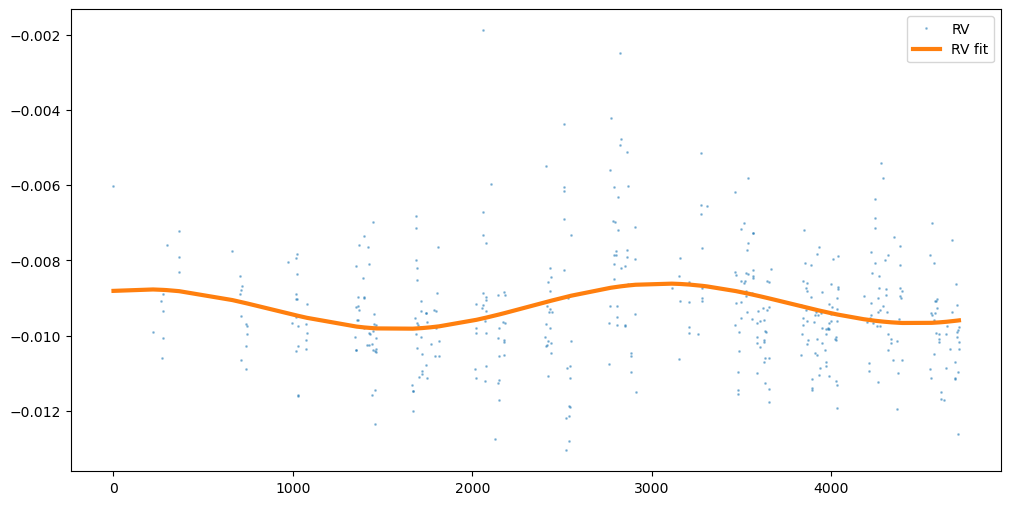

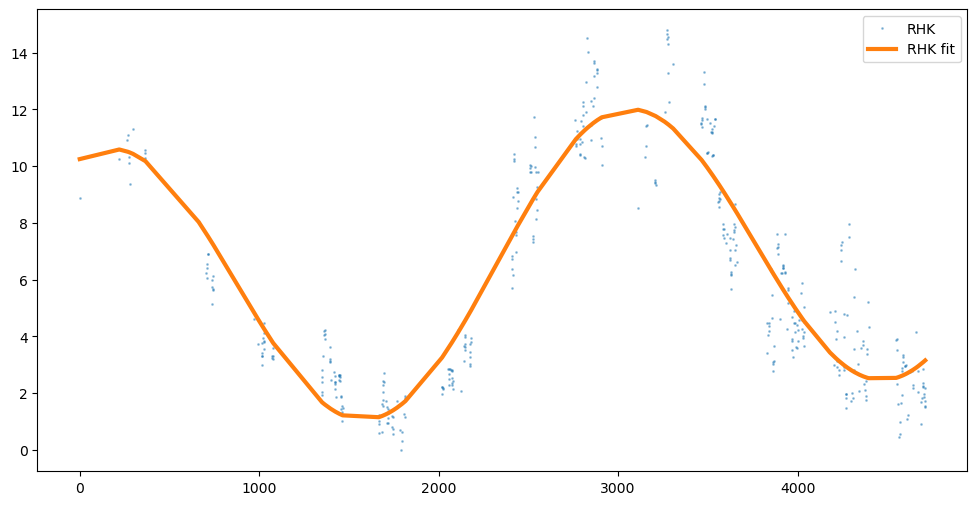

In [4]:
def shared_core(x, b, P, phi):
    return b*x + np.sin(2*np.pi*x/P + phi)

# RV model
def model_rv(x, a1, c1, b, P, phi):
    return a1 + c1 * shared_core(x, b, P, phi)

# RHK model
def model_rhk(x, a2, c2, b, P, phi):
    return a2 + c2 * shared_core(x, b, P, phi)

# Joint model for curve_fit
def joint_model(x_concat,
                a1, c1,
                a2, c2,
                b, P, phi):

    n = len(x_concat) // 2

    x1 = x_concat[:n]
    x2 = x_concat[n:]

    y1 = model_rv(x1, a1, c1, b, P, phi)
    y2 = model_rhk(x2, a2, c2, b, P, phi)

    return np.concatenate([y1, y2])

x = t_full[series_index[0]]  # same for both series, but just take from one
x_concat = np.concatenate([t_full[series_index[0]], t_full[series_index[1]]])
y_rv = y_full[series_index[0]]
y_rhk = y_full[series_index[1]]


y_concat = np.concatenate([y_rv, y_rhk])


a1_0 = np.mean(y_rv)
c1_0 = np.std(y_rv)

a2_0 = np.mean(y_rhk)
c2_0 = np.std(y_rhk)

b0 = 0
P0 = 4000   # adjust if needed
phi0 = 0

p0 = [
    a1_0, c1_0,
    a2_0, c2_0,
    b0, P0, phi0
]


params, covar = curve_fit(
    joint_model,
    x_concat,
    y_concat,
    p0=p0,
    maxfev=20000
)

(
    a1, c1,
    a2, c2,
    b, P, phi
) = params

print("Shared parameters:")
print(f"b    = {b}")
print(f"P    = {P}")
print(f"phi  = {phi}")


rv_fit = model_rv(x, a1, c1, b, P, phi)
rhk_fit = model_rhk(x, a2, c2, b, P, phi)


plt.figure(figsize=(12,6))

plt.plot(x, y_rv, '.', alpha=0.4, markersize=2, label='RV')
plt.plot(x, rv_fit, linewidth=3, label='RV fit')
plt.legend()
plt.show()


plt.figure(figsize=(12,6))
plt.plot(x, y_rhk, '.', alpha=0.4, markersize=2, label='RHK')
plt.plot(x, rhk_fit, linewidth=3, label='RHK fit')

plt.legend()
plt.show()

In [5]:
y_full[series_index[0]] = y_full[series_index[0]] - rv_fit
y_full[series_index[1]] = y_full[series_index[1]] - rhk_fit

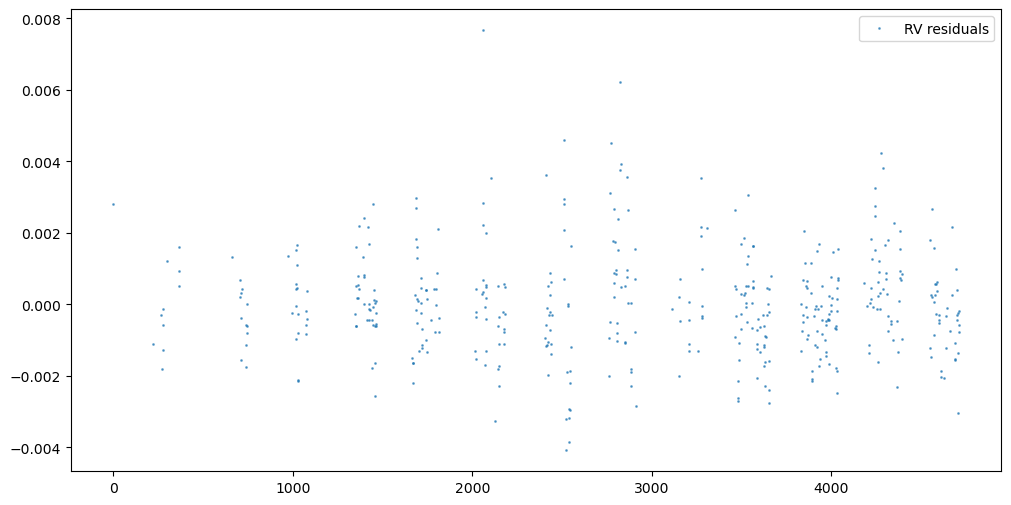

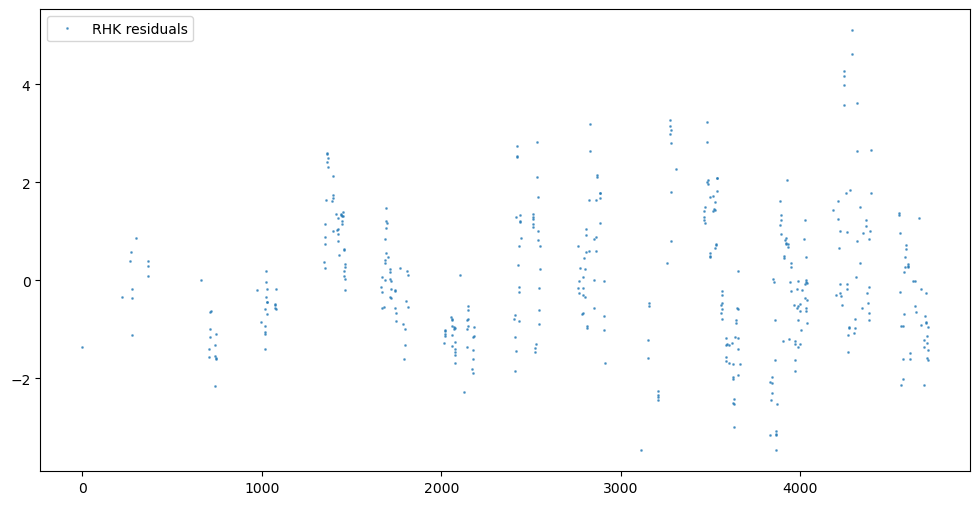

In [6]:
plt.figure(figsize=(12,6))
plt.plot(x, y_full[series_index[0]], '.', alpha=0.6, markersize=2, label='RV residuals')
plt.legend()

plt.figure(figsize=(12,6))
plt.plot(x, y_full[series_index[1]], '.', alpha=0.6, markersize=2, label='RHK residuals')
plt.legend()    

In [7]:
class MultiSeriesKernel(term.MultiSeriesKernel):
  def _grad_param(self, grad_dU=None, grad_dV=None):
    if grad_dU is not None or grad_dV is not None:
      raise NotImplementedError()
    return super()._grad_param()

In [8]:
stds = [np.std(y_full[series_index[0]]), np.std(y_full[series_index[1]])]
# sig = np.var(y_full[series_index[0]]) 
sig = 1.0

prot = 38.0
Q = 1.2

rvjit = 0.1*stds[0]
rhkjit = 0.1*stds[1]

rho = 40.0
eta = 0.25



C = cov.Cov(
  t_full,
  err=term.Error(yerr_full),
  rv_jit=term.InstrumentJitter(series_index[0], rvjit),
  rhk_jit=term.InstrumentJitter(series_index[1], rhkjit),
  rot = MultiSeriesKernel(term.MEPKernel(sig,prot,rho,eta), series_index, 
        np.array([stds[0], stds[1]]), 
        np.array([stds[0], 0.0])
    ),
  )



In [9]:
rvjit_max = 5*stds[0]
rhkjit_max = 5*stds[1]

prot_min = 25.0
prot_max = 40.0
Q_min = 0.9
Q_max = 3.0

alpha_0_max = 10*stds[0]
alpha_1_max = 5*stds[1]
beta_0_max  = 10*stds[0]

rho_min = 10.0
rho_max = 200.0
eta_min = 0.1
eta_max = 1.0

gamma_0_max = 5*stds[0]
gamma_1_max = 5*stds[1]

planet_p_min = 20.0
planet_p_max = 30.0
planet_A_min = 0.000005
planet_A_max = 0.05
planet_B_min = 0.000005
planet_B_max = 0.05

bounds_list = [
    (0.0, rvjit_max),                     # rv_jit.sig
    (0.0, rhkjit_max),                     # rhk_jit.sig
    
    (prot_min, prot_max),                 # rot.P0 (period)
    # (Q_min, Q_max),                      # rot.Q (quality factor)
    (rho_min, rho_max),                    # rot.rho (frequency)
    (eta_min, eta_max),                    # rot.eta (damping)
    (0, alpha_0_max),         # rot.alpha_0 (set lower bound to zero)
    (-alpha_1_max, alpha_1_max),         # rot.alpha_1
    (-beta_0_max, beta_0_max),         # rot.beta_0      # rot.beta_1
    # (0.01,0.99), 
    (-0.5, 0.5),         # delta_0 (offset for series 0)
    (-2,2),    
    (planet_p_min, planet_p_max),                         # P_planet
    (planet_A_min, planet_A_max),                          # A_planet
    (planet_B_min, planet_B_max),                          # B_planet

]

# print(rvjit_max)
# print(rhkjit_max)
# print(alpha_0_max)
# print(bounds_list)

In [10]:
C.param

['rv_jit.sig',
 'rhk_jit.sig',
 'rot.sig',
 'rot.P',
 'rot.rho',
 'rot.eta',
 'rot.alpha_0',
 'rot.alpha_1',
 'rot.beta_0',
 'rot.beta_1']

In [11]:
def negloglike(x, y, C, params, params_inds, t_full, series_index, rv_std = 1.0, inject_planet=False):
  
  C.set_param(x[:len(params)], params)

  y_model = y.copy()

  if inject_planet == True:
    y_model[series_index[0]] -= (mf.planet_injection(t_full[series_index[0]], x[10], x[11], x[12]) )/rv_std

  y_model[series_index[0]] -=  x[8]
  y_model[series_index[1]] -=  x[9]

  # gradient§
  nll = -C.loglike(y_model)

  lg = C.loglike_grad()
  dL_dy = np.asarray(lg[0]).reshape(-1)      # shape (N_total,) 
  dL_dparams = np.asarray(lg[1]).reshape(-1) # shape (12,)      

  base_grad = - dL_dparams[params_inds]

  # gradients wrt delta (additive offsets)
  grad_delta_0 = np.sum(dL_dy[series_index[0]])
  grad_delta_1 = np.sum(dL_dy[series_index[1]])


  if inject_planet == True:
    argument = 2 * np.pi * t_full[series_index[0]] / (x[10]+0.000001)
    grad_planet_p = np.sum(dL_dy[series_index[0]] * (1/rv_std)*(-x[11] * 2 * np.pi * t_full[series_index[0]] / ((x[10]+0.000001)**2) * np.cos(argument)+x[12]*2*np.pi*t_full[series_index[0]]/((x[10]+0.000001)**2)*np.sin(argument))) 
    grad_planet_a = np.sum(dL_dy[series_index[0]] * (1/rv_std)*(np.sin(argument)))
    grad_planet_b = np.sum(dL_dy[series_index[0]] * (1 / rv_std) * (np.cos(argument)))
    nll_grad = np.concatenate([np.asarray(base_grad).ravel(), np.array([grad_delta_0, grad_delta_1, grad_planet_p, grad_planet_a, grad_planet_b])])
  else:
    nll_grad = np.concatenate([np.asarray(base_grad).ravel(), np.array([grad_delta_0, grad_delta_1])])
  # nll_grad = -C.loglike_grad()[1][fitted]

  return (nll, nll_grad)


In [12]:
from scipy.optimize import fmin_l_bfgs_b


params_inds = [k for k, key in enumerate(C.param) if key != 'rot.sig' and key != "rot.beta_1"]  
params = [C.param[k] for k in params_inds]

x0 = C.get_param(params)
x0 = np.append(x0,[-0.001, 0.001, 26.431, 0.0005, 0.0005])   # Added initial guesses for new parameters (delta_0, delta_1, planet parameters)


result = fmin_l_bfgs_b(negloglike, x0, args=(y_full, C, params, params_inds, t_full, series_index, 1.0, True), bounds=bounds_list)
xbest = result[0]

C.set_param(xbest[:len(params)], params)
C.set_param([0.0], ['rot.beta_1'])


print(params)
print(xbest)

['rv_jit.sig', 'rhk_jit.sig', 'rot.P', 'rot.rho', 'rot.eta', 'rot.alpha_0', 'rot.alpha_1', 'rot.beta_0']
[ 1.12322302e-03  2.43571608e-01  3.79816422e+01  3.99904326e+01
  5.50975896e-01  3.39122507e-04  1.38021914e+00  4.09464943e-03
  1.04401598e-05 -1.42895003e-02  2.63877560e+01  5.00000000e-06
  4.88801035e-04]


In [13]:
def plot_fit(t_full, y_full, yerr_full, C, xbest, series_index, rv_std = 1.0, output_name = 'fit_plot.png', return_residuals=True, inject_planet=True):

    tsmooth = np.linspace(np.min(t_full), np.max(t_full), 1000)
    _, axs = plt.subplots(2, 1, sharex=True, figsize=(15, 10))
    # params = ['rv_jit.sig', 'rhk_jit.sig', 'rot.P0', 'rot.Q', 'rot.alpha_0', 'rot.alpha_1', 'rot.beta_0']
    # C.set_param(xbest[:len(params)], params)
    for k in range(2):
    # Predict time series k

        C.kernel['rot'].set_conditional_coef(series_id=k)
        # C.kernel['rot'].set_conditional_coef(series_id=k)
        # fc_unnorm = (fc - xbest[10]) / ((1.0 - xbest[10]) / 2.0) - 1
        y_model = y_full.copy()
        
        if inject_planet == True:
            y_model[series_index[0]] -= (mf.planet_injection(t_full[series_index[0]], xbest[10], xbest[11], xbest[12]))/rv_std

        y_model[series_index[0]] -= xbest[8]
        y_model[series_index[1]] -= xbest[9]
        
        

        mu, var = C.conditional(y_model, tsmooth, calc_cov='diag')
        mu_res, _ = C.conditional(y_model, t_full[series_index[k]], calc_cov='diag')
  
        ax = axs[k]
        if k ==0 :
            ax.errorbar(t_full[series_index[k]], y_model[series_index[k]], yerr_full[series_index[k]], fmt='.', color='k', label='meas.')
            if inject_planet == True:
                ax.plot(t_full[series_index[k]], mf.planet_injection(t_full[series_index[k]], xbest[10], xbest[11], xbest[12])/rv_std, 'r', label='injected planet')
        if k == 1:
            ax.errorbar(t_full[series_index[k]], y_model[series_index[k]], yerr_full[series_index[k]], fmt='.', color='k', label='meas.')
        ax.fill_between(tsmooth,
            mu - np.sqrt(var),
            mu + np.sqrt(var),
            color='g',
            alpha=0.5)
        ax.plot(tsmooth, mu, 'g', label='predict.')
        ax.set_ylabel(f'$y_{k}$')

        if return_residuals==True:
            if k == 0:
                res_rv = y_model[series_index[k]] - mu_res
            else:
                res_rhk = y_model[series_index[k]] - mu_res

    ax.set_xlabel('$t$')
    axs[0].legend()
    plt.savefig(output_name)
    if return_residuals==True:
        return tsmooth, mu,res_rv, res_rhk
    else:
        return tsmooth, mu
    
    

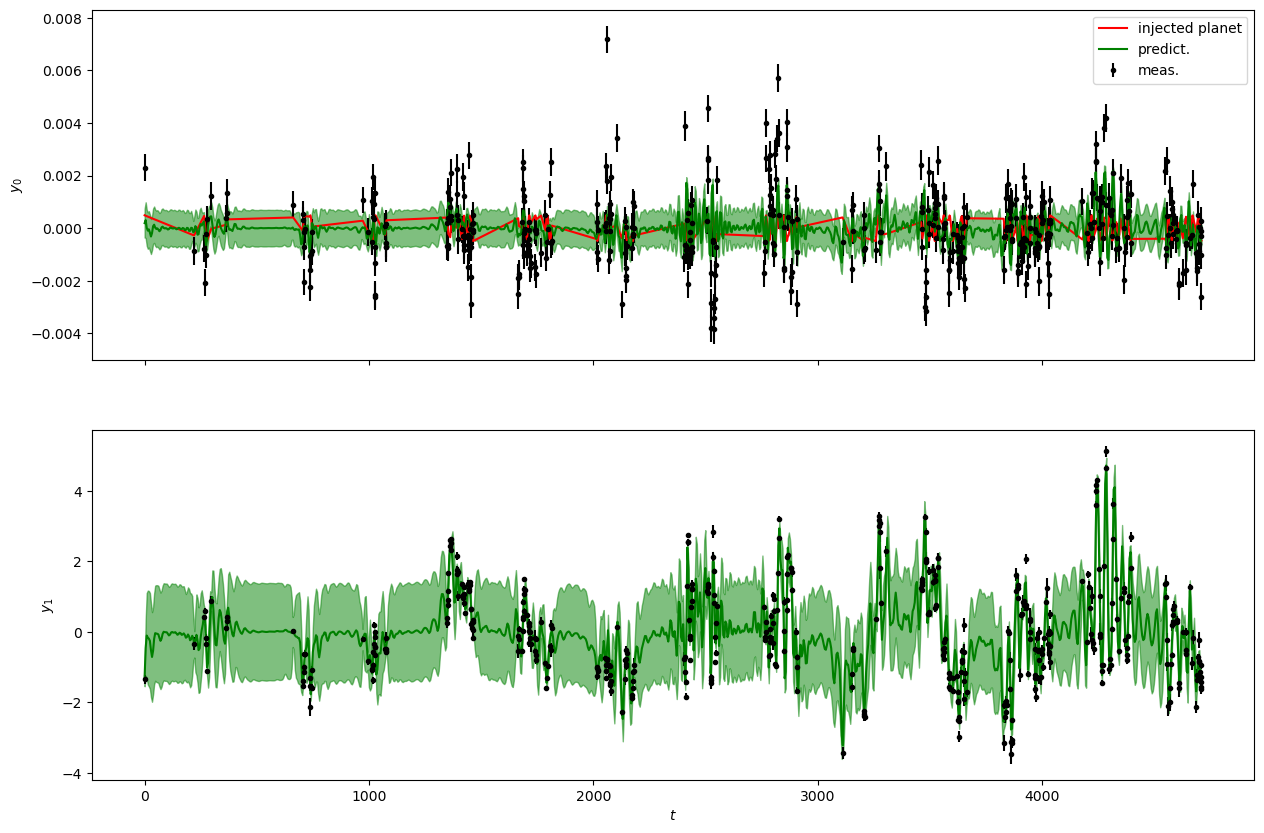

In [14]:
tsmooth, mu = plot_fit(t_full, y_full, yerr_full, C, xbest, series_index, 1.0, output_name='fit_plot.png', return_residuals=False, inject_planet=True)

In [15]:
def log_prior(theta):
    # unpack theta (added delta_0, delta_1 as final two entries)
    # rv_jit, rhk_jit, rot_P0, rot_Q, rot_alpha_0, rot_alpha_1, rot_beta_0, delta_0, delta_1, planet_period, planet_A, planet_B = theta
    # if 0.0 < rv_jit < rvjit_max and 0.0 < rhk_jit < rhkjit_max and prot_min < rot_P0 < prot_max and Q_min < rot_Q < Q_max and 0.0 < rot_alpha_0 < alpha_0_max and -alpha_1_max < rot_alpha_1 < alpha_1_max and -beta_0_max < rot_beta_0 < beta_0_max and -0.5 < delta_0 < 0.5 and -2 < delta_1 < 2 and planet_p_min < planet_period < planet_p_max and planet_A_min < planet_A < planet_A_max and planet_B_min < planet_B < planet_B_max:
    rv_jit, rhk_jit, rot_P0, rot_rho, rot_eta, rot_alpha_0, rot_alpha_1, rot_beta_0, delta_0, delta_1, planet_period, planet_A, planet_B = theta
    if 0.0 < rv_jit < rvjit_max and 0.0 < rhk_jit < rhkjit_max and prot_min < rot_P0 < prot_max and rho_min < rot_rho < rho_max and eta_min < rot_eta < eta_max and 0.0 < rot_alpha_0 < alpha_0_max and -alpha_1_max < rot_alpha_1 < alpha_1_max and -beta_0_max < rot_beta_0 < beta_0_max and -0.5 < delta_0 < 0.5 and -2 < delta_1 < 2 and planet_p_min < planet_period < planet_p_max and planet_A_min < planet_A < planet_A_max and planet_B_min < planet_B < planet_B_max:
        return 0
    return -np.inf

def log_probability(theta, y, C):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + -1*negloglike(theta, y, C, params, params_inds, t_full, series_index, 1.0, True)[0]

x0 = xbest.copy()

# x0 = map_sample[[0,1,6,7,8,9,10]]
print(x0)
print(log_prior(x0))    

# x0 = [0.03, 0.2, 1500.0, 0.015, 4.0, 4.0, 4.0]
ndim = len(x0)
pos = x0 + 1e-5 * np.random.randn(ndim*3, ndim)
# pos = x0 
nwalkers, ndim = pos.shape


sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(y_full, C)
)
sampler.run_mcmc(pos, 3000, progress=True);

[ 1.12322302e-03  2.43571608e-01  3.79816422e+01  3.99904326e+01
  5.50975896e-01  3.39122507e-04  1.38021914e+00  4.09464943e-03
  1.04401598e-05 -1.42895003e-02  2.63877560e+01  5.00000000e-06
  4.88801035e-04]
-inf


  0%|          | 0/3000 [00:00<?, ?it/s]/opt/anaconda3/envs/sleaf/lib/python3.10/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 3000/3000 [01:16<00:00, 39.03it/s]


['rv_jit.sig', 'rhk_jit.sig', 'rot.P', 'rot.rho', 'rot.eta', 'rot.alpha_0', 'rot.alpha_1', 'rot.beta_0', 'delta_0', 'delta_1', 'planet_p', 'planet_A', 'planet_B']


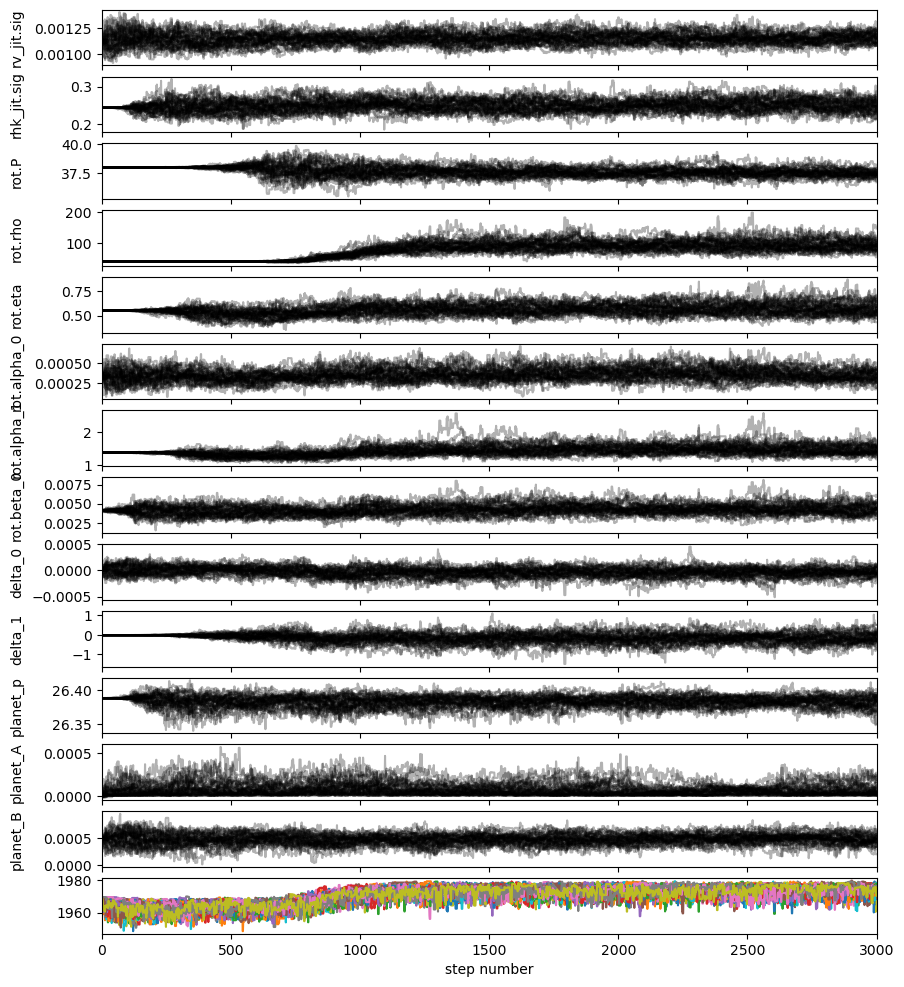

In [21]:
# ig, axes = plt.subplots(13, figsize=(10, 12), sharex=True)
ig, axes = plt.subplots(len(params) + 6, figsize=(10, 12), sharex=True)
samples = sampler.get_chain()

labels = params + ['delta_0', 'delta_1', 'planet_p', 'planet_A', 'planet_B']
# labels = params + ['pcyc','phi','k','gamma_0', 'gamma_1', 'delta_0', 'delta_1']
print(labels)
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)
    

axes[-1].set_xlabel("step number");

logp = sampler.get_log_prob(flat=False)
axes[-1].plot(logp)

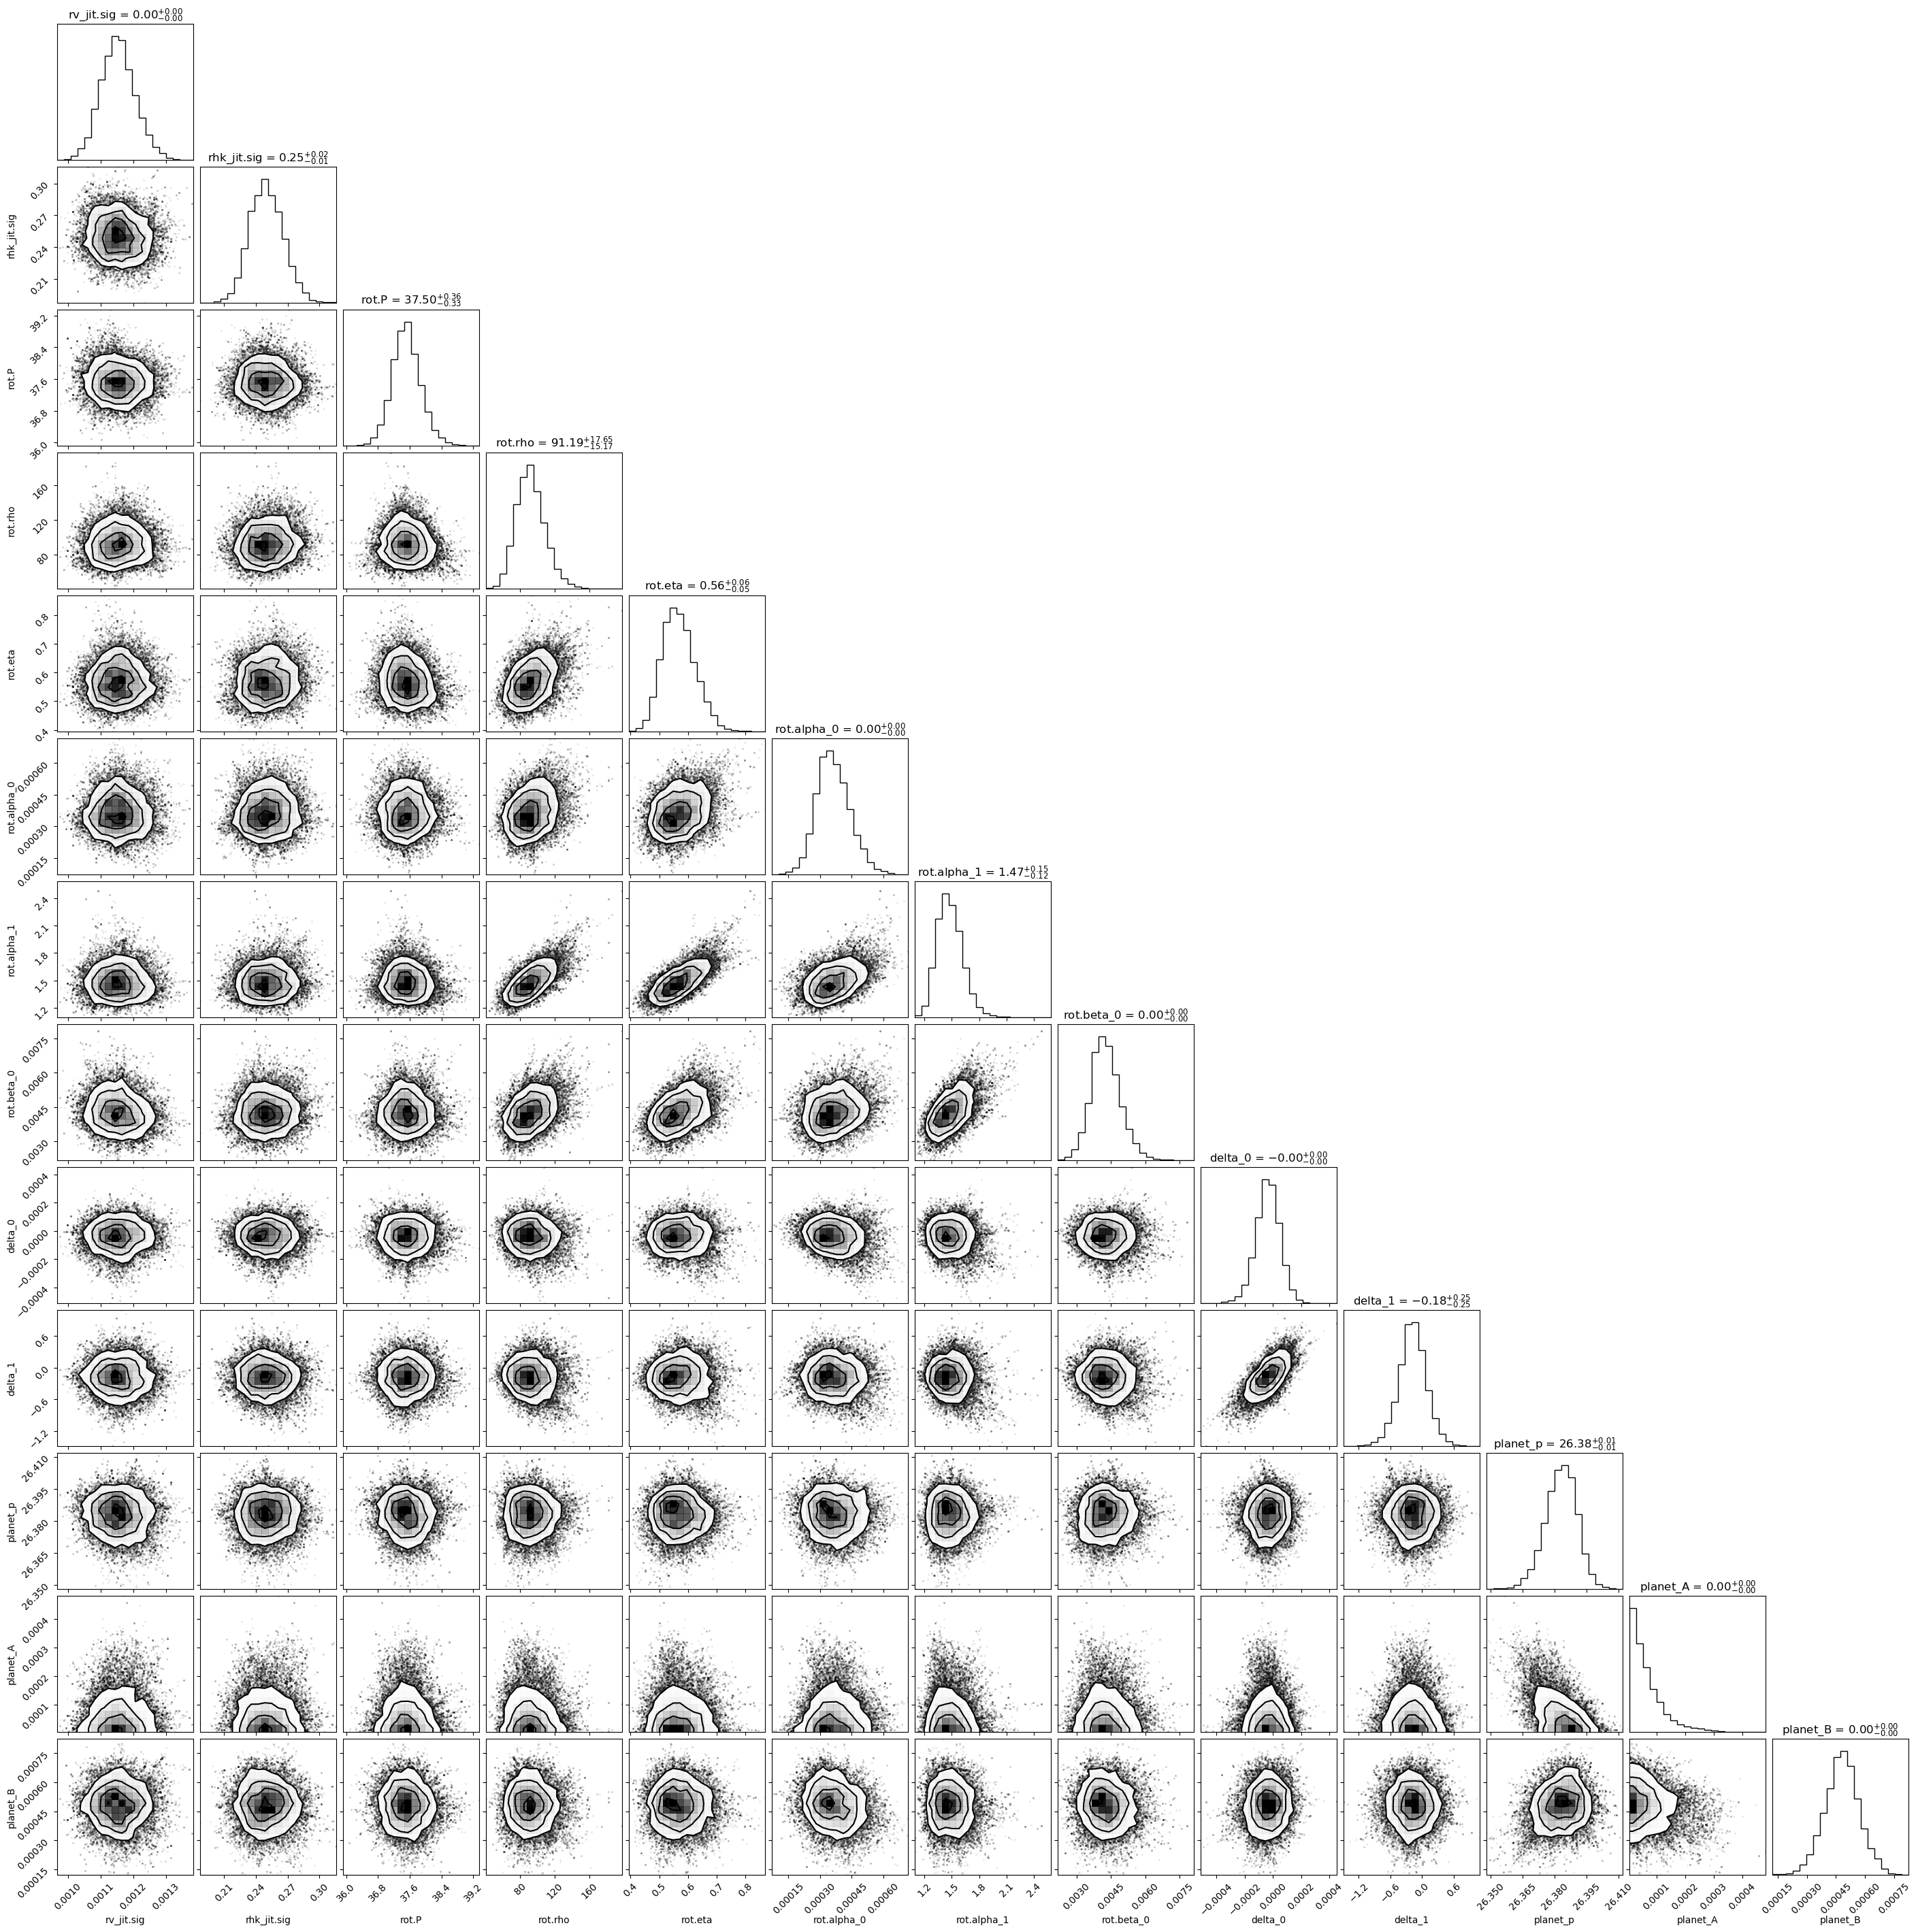

In [17]:
import corner

flat_samples = sampler.get_chain(discard=1500, thin=1, flat=True)

# true_vals = [0.0, 0.0, prot, Q, stds[0], stds[1], stds[0], 8000, np.pi, 0.28, gamma_0, gamma_1, delta_0, delta_1, 100.0, 0.5, 0.5]

fig = corner.corner(
    flat_samples, labels=labels, show_titles=True
);


MAP index (in flattened, post-burn chain): 54713
MAP log-posterior: 1979.9057773981472
MAP sample (theta): [ 1.14830804e-03  2.54346516e-01  3.73762350e+01  9.10813150e+01
  5.27402317e-01  3.31017142e-04  1.33603186e+00  4.14240797e-03
 -3.44938306e-05 -1.20713056e-01  2.63858949e+01  1.81056424e-05
  4.64537523e-04]


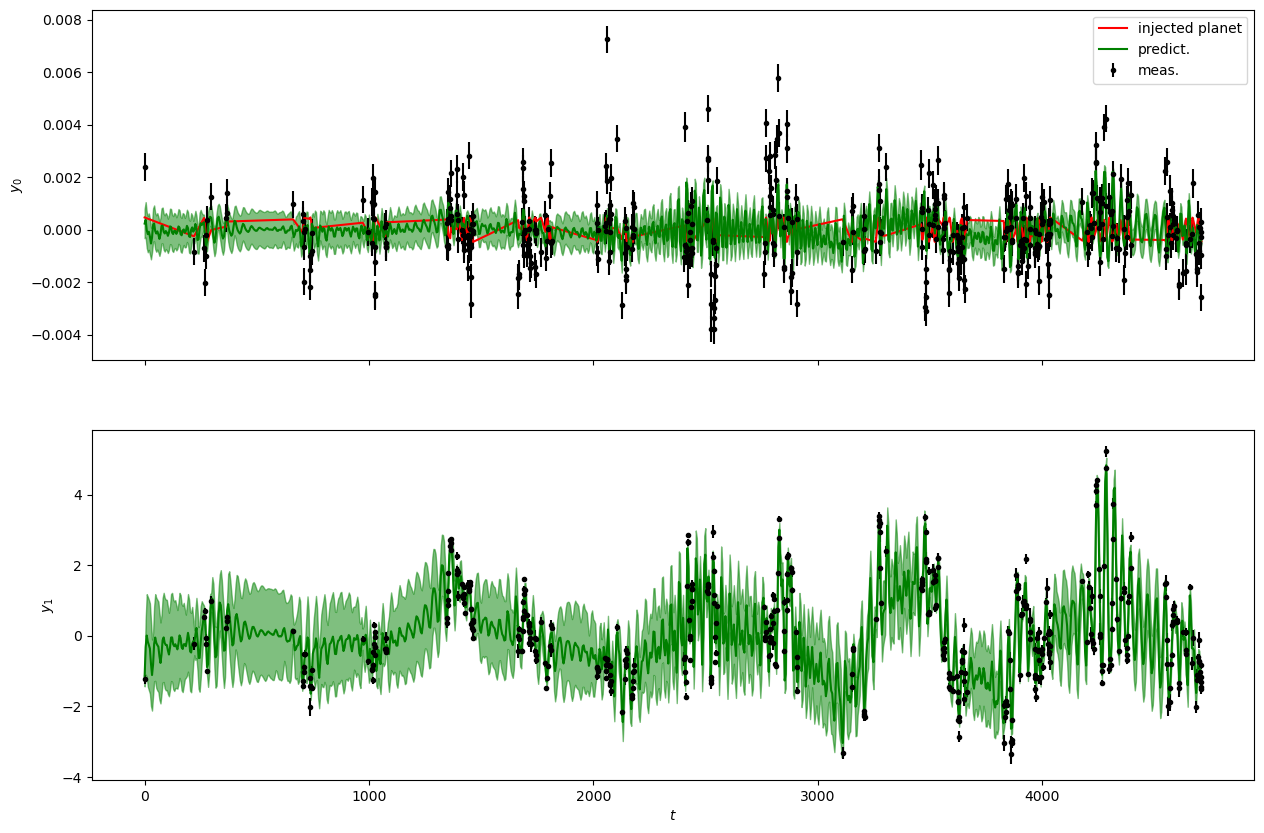

In [18]:
burn = 1500   
thin = 1

flat_samples = sampler.get_chain(discard=burn, thin=thin, flat=True)   # shape (n_samples, ndim)
flat_logp    = sampler.get_log_prob(discard=burn, thin=thin, flat=True) # shape (n_samples,)

finite_mask = np.isfinite(flat_logp)
flat_samples = flat_samples[finite_mask]
flat_logp    = flat_logp[finite_mask]

map_idx = np.argmax(flat_logp)
map_sample = flat_samples[map_idx]
map_logp = flat_logp[map_idx]

print("MAP index (in flattened, post-burn chain):", map_idx)
print("MAP log-posterior:", map_logp)
print("MAP sample (theta):", map_sample)

# np.save("sun_map_sample.npy", map_sample)

C.set_param(map_sample[:len(params)], params)
C.set_param([0.0], ['rot.beta_1'])
C.set_param([np.var(y_full)], ['rot.sig'])

tsmooth, mu, res_rv, res_rhk = plot_fit(t_full, y_full, yerr_full, C, map_sample, series_index,1.0,output_name='fit_plot.png', return_residuals=True, inject_planet=True)

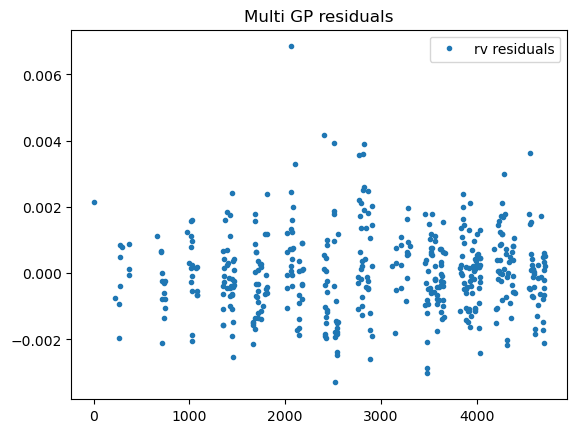

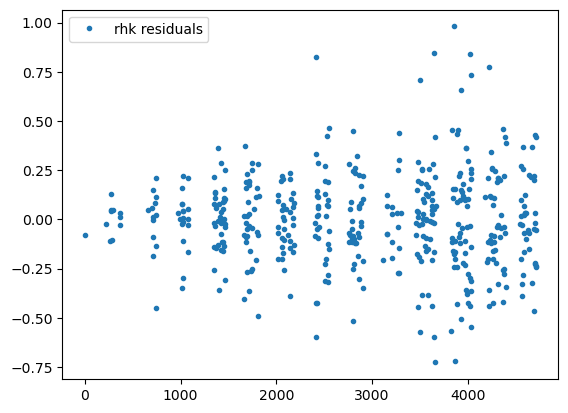

In [22]:
plt.figure()
plt.title("Multi GP residuals")
plt.plot(t_full[series_index[0]], res_rv, ".", label='rv residuals')
plt.legend()
plt.figure()
plt.plot(t_full[series_index[1]], res_rhk, ".", label='rhk residuals')
# plt.ylim(-1.5,1.5)
plt.legend()
plt.show()

In [41]:
(np.sqrt(map_sample[-2]**2 + map_sample[-1]**2) - np.sqrt(0.001**2 + 0.001**2)  )/ np.sqrt(0.001**2 + 0.001**2)

np.float64(-0.003837789883448702)

In [49]:
np.sqrt(0.0005**2 + 0.0005**2)  

np.float64(0.0007071067811865475)

In [23]:
(np.sqrt(map_sample[-2]**2 + map_sample[-1]**2))

np.float64(0.0004648902283763798)